In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("环境就绪")


环境就绪


In [3]:
# === 生成模拟信贷数据（类似于银行真实数据）===
np.random.seed(42)
n = 5000

# 借款人特征
age = np.random.normal(38, 10, n).astype(int)
age = np.clip(age, 22, 65)

income = np.random.lognormal(mean=8.8, sigma=0.5, size=n).astype(int)  # 年收入（元）
income = np.clip(income, 30000, 2000000)

loan_amount = (income * np.random.uniform(0.1, 0.8, n)).astype(int)
loan_amount = np.clip(loan_amount, 5000, 1000000)

credit_score = np.random.normal(650, 80, n).astype(int)
credit_score = np.clip(credit_score, 300, 850)

employment_years = np.random.exponential(5, n).astype(int)
employment_years = np.clip(employment_years, 0, 40)

debt_ratio = np.random.uniform(0, 0.7, n)
debt_ratio = np.round(debt_ratio, 2)

has_house = np.random.choice([0, 1], n, p=[0.5, 0.5])
has_car = np.random.choice([0, 1], n, p=[0.4, 0.6])

# 违约标签（逻辑回归式概率）
log_odds = (
    -0.03 * credit_score / 10
    + 0.5 * debt_ratio * 10
    - 0.8 * has_house
    - 0.3 * has_car
    - 0.02 * employment_years
    - 0.001 * age * 0.3
    + np.random.normal(0, 0.5, n)
)
prob_default = 1 / (1 + np.exp(-log_odds))
y = (prob_default > np.percentile(prob_default, 85)).astype(int)  # 约 15% 违约率

df = pd.DataFrame({
    '年龄': age,
    '年收入': income,
    '贷款金额': loan_amount,
    '信用评分': credit_score,
    '工作年限': employment_years,
    '负债率': debt_ratio,
    '有房产': has_house,
    '有车': has_car,
    '违约': y
})

# 保存
df.to_csv('loan_data.csv', index=False)
print(f"数据量: {len(df)} 条")
print(f"违约率: {y.mean()*100:.1f}%")
print(df.head(10))


数据量: 5000 条
违约率: 15.0%
   年龄    年收入   贷款金额  信用评分  工作年限   负债率  有房产  有车  违约
0  42  30000   9746   850     4  0.43    1   1   0
1  36  30000   5163   695     0  0.25    0   0   0
2  44  30000   5000   599     0  0.08    0   1   0
3  53  30000   5000   677     1  0.31    0   1   0
4  35  30000  15240   792     6  0.51    0   0   0
5  35  30000   5000   796     0  0.67    1   1   0
6  53  30000  10075   603     9  0.26    1   0   0
7  45  30000  18817   670     0  0.38    0   0   0
8  33  30000   9181   535     0  0.60    1   0   0
9  43  30000  19029   715     2  0.23    1   0   0


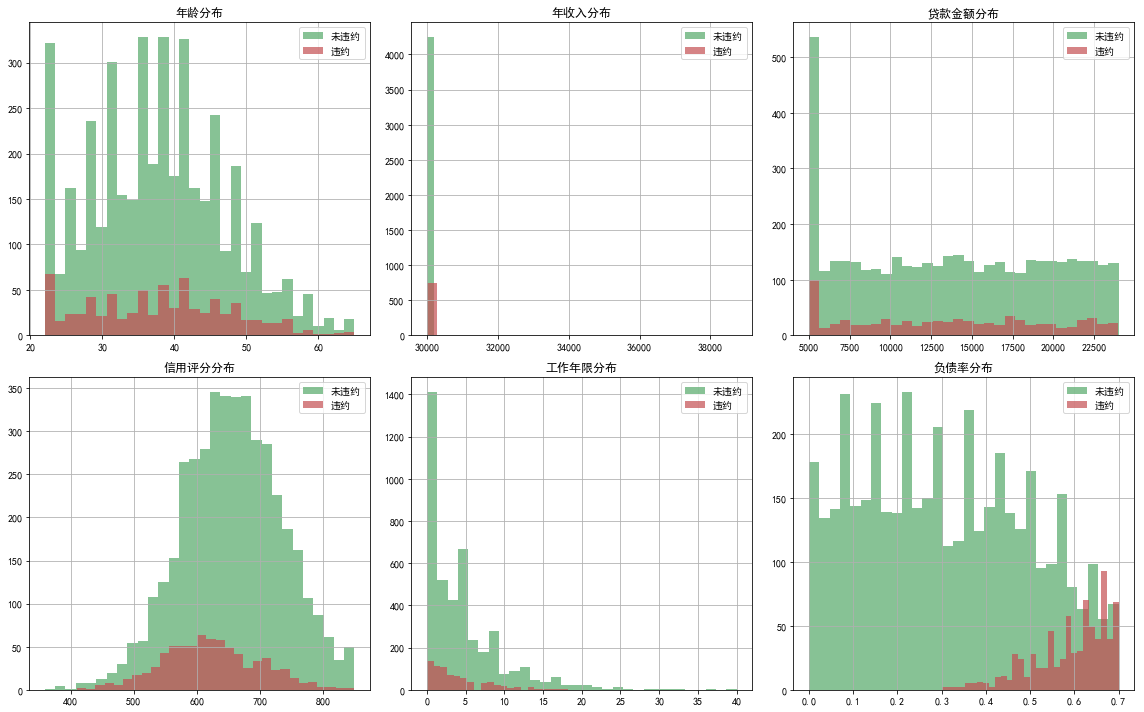

违约 vs 未违约 均值对比:
       年龄       年收入      贷款金额    信用评分  工作年限   负债率
违约                                               
0   37.77  30002.26  13653.92  655.68  4.44  0.31
1   37.97  30013.29  13643.97  622.67  3.92  0.59


In [4]:
# === 违约 vs 非违约 对比分析 ===
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features = ['年龄', '年收入', '贷款金额', '信用评分', '工作年限', '负债率']
titles = ['年龄分布', '年收入分布', '贷款金额分布', '信用评分分布', '工作年限分布', '负债率分布']

for i, (feat, title) in enumerate(zip(features, titles)):
    row, col = i // 3, i % 3
    df[df['违约'] == 0][feat].hist(bins=30, alpha=0.7, label='未违约', color='#55A868', ax=axes[row, col])
    df[df['违约'] == 1][feat].hist(bins=30, alpha=0.7, label='违约', color='#C44E52', ax=axes[row, col])
    axes[row, col].set_title(title)
    axes[row, col].legend()
    axes[row, col].set_xlabel('')

plt.tight_layout()
plt.show()

# 数字对比
print("违约 vs 未违约 均值对比:")
print(df.groupby('违约')[features].mean().round(2))


In [5]:
# === 准备训练数据 ===
# X = 特征（输入），y = 标签（要预测的）
feature_cols = ['年龄', '年收入', '贷款金额', '信用评分', '工作年限', '负债率', '有房产', '有车']
X = df[feature_cols]
y = df['违约']

# 拆分：80% 训练模型，20% 测试模型效果
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集: {len(X_train)} 条")
print(f"测试集: {len(X_test)} 条")
print(f"测试集违约率: {y_test.mean()*100:.1f}%")


训练集: 4000 条
测试集: 1000 条
测试集违约率: 15.3%


=== 随机森林模型评估 ===
准确率: 89.8%
AUC: 0.945


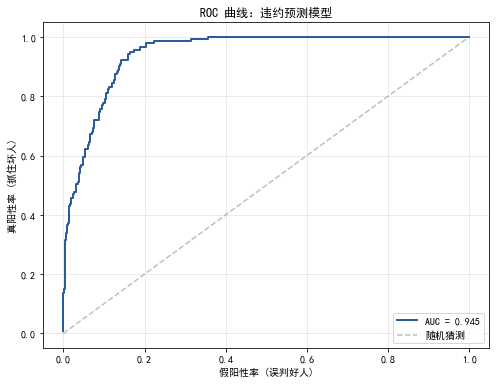

In [6]:
# === 随机森林：更强的模型 ===
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== 随机森林模型评估 ===")
print(f"准确率: {rf.score(X_test, y_test)*100:.1f}%")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

# ROC曲线
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2b5c9e', linewidth=2, label=f'AUC = {roc_auc_score(y_test, y_prob_rf):.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='随机猜测')
plt.xlabel('假阳性率 (误判好人)')
plt.ylabel('真阳性率 (抓住坏人)')
plt.title('ROC 曲线：违约预测模型')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



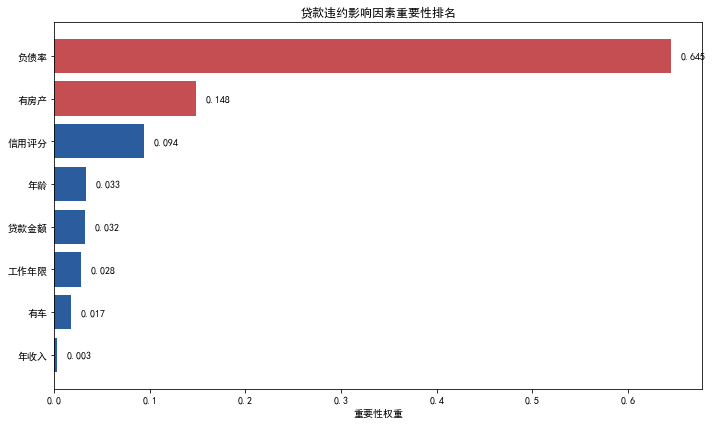

特征重要性排名:
     特征       重要性
5   负债率  0.645239
6   有房产  0.148035
3  信用评分  0.093931
0    年龄  0.033057
2  贷款金额  0.032164
4  工作年限  0.027594
7    有车  0.017122
1   年收入  0.002859


In [7]:
# === 特征重要性 ===
importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': rf.feature_importances_
}).sort_values('重要性', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#C44E52' if v > 0.1 else '#2b5c9e' for v in importance['重要性']]
plt.barh(importance['特征'][::-1], importance['重要性'][::-1], color=colors[::-1])
plt.title('贷款违约影响因素重要性排名')
plt.xlabel('重要性权重')
for i, v in enumerate(importance['重要性'][::-1]):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("特征重要性排名:")
print(importance)


贷款违约预测 — 银行风控模型

项目背景
模拟银行真实信贷数据 5,000 条，违约率 15%
使用机器学习构建违约预测模型，评估哪些客户应批准贷
核心发现

1.违约者画像
负债率高、信用评分低、工作年限短的借款人违约风险显著更高
有房产、有车的人违约率明显低于无产者
2.预测模型效果
随机森林模型 AUC = 0.945，能有效区分好客户和坏客户
模型准确率 89.8%

3.影响违约的关键因素（重要性排名）
负债率：最重要因素
是否有房产：第二关键（有房 = 更低风险）
信用评分、工作年限、收入等也有影响

技术栈
**Pandas / NumPy**：数据生成与清洗
- **Matplotlib / Seaborn**：特征分布可视化
- **Scikit-learn**：逻辑回归 + 随机森林 + AUC/ROC 评估

## 业务建议
审批贷款时优先关注负债率和房产情况，对高负债无房客户提高审核门槛或调整利率。
